# 05 Amplitude Damping

## Theory
Amplitude damping models energy loss, such as decay from |1> to |0>. In optical or hardware-inspired channels, this is useful for studying loss-like physical noise.

In [1]:
# Common imports used in this notebook
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator
from qiskit_aer.noise import NoiseModel, pauli_error, depolarizing_error, amplitude_damping_error

np.random.seed(42)
plt.style.use("seaborn-v0_8-whitegrid")

In [2]:
# BB84 helper functions
def random_bits(n):
    """Generate n random classical bits."""
    return np.random.randint(0, 2, size=n)


def random_bases(n):
    """Generate n random bases: 0 means Z basis, 1 means X basis."""
    return np.random.randint(0, 2, size=n)


def prepare_bb84_qubit(bit, basis):
    """Create one BB84 qubit circuit.

    bit=0/1 is the secret bit.
    basis=0 prepares in Z basis; basis=1 prepares in X basis.
    """
    qc = QuantumCircuit(1, 1)
    if bit == 1:
        qc.x(0)
    if basis == 1:
        qc.h(0)
    return qc


def measure_bb84_qubit(qc, basis):
    """Measure the qubit in Bob's selected basis."""
    if basis == 1:
        qc.h(0)
    qc.measure(0, 0)
    return qc


def run_single_shot(qc, simulator=None, noise_model=None):
    """Run one circuit once and return measured bit as an integer."""
    simulator = simulator or AerSimulator(noise_model=noise_model)
    compiled = transpile(qc, simulator)
    result = simulator.run(compiled, shots=1).result()
    counts = result.get_counts()
    return int(max(counts, key=counts.get))


def sift_key(alice_bits, alice_bases, bob_bases, bob_bits):
    """Keep only positions where Alice and Bob used the same basis."""
    mask = alice_bases == bob_bases
    return alice_bits[mask], bob_bits[mask], mask


def qber(alice_key, bob_key):
    """Quantum Bit Error Rate: fraction of mismatched sifted bits."""
    if len(alice_key) == 0:
        return 0.0
    return float(np.mean(alice_key != bob_key))


def simulate_bb84(n=256, noise_model=None, eve=False):
    """Simulate BB84 with optional noise and optional intercept-resend Eve attack."""
    alice_bits = random_bits(n)
    alice_bases = random_bases(n)
    bob_bases = random_bases(n)
    bob_bits = []
    simulator = AerSimulator(noise_model=noise_model)

    for bit, alice_basis, bob_basis in zip(alice_bits, alice_bases, bob_bases):
        qc = prepare_bb84_qubit(int(bit), int(alice_basis))

        if eve:
            # Eve randomly measures and resends the qubit, which disturbs states
            # whenever she chooses the wrong basis.
            eve_basis = int(random_bases(1)[0])
            qc = measure_bb84_qubit(qc, eve_basis)
            eve_bit = run_single_shot(qc, simulator=simulator)
            qc = prepare_bb84_qubit(eve_bit, eve_basis)

        qc = measure_bb84_qubit(qc, int(bob_basis))
        bob_bits.append(run_single_shot(qc, simulator=simulator))

    bob_bits = np.array(bob_bits)
    alice_key, bob_key, mask = sift_key(alice_bits, alice_bases, bob_bases, bob_bits)
    return {
        "alice_bits": alice_bits,
        "alice_bases": alice_bases,
        "bob_bases": bob_bases,
        "bob_bits": bob_bits,
        "alice_key": alice_key,
        "bob_key": bob_key,
        "sift_mask": mask,
        "sifted_key_length": int(mask.sum()),
        "qber": qber(alice_key, bob_key),
    }

,Damping gamma,Sifted key length,QBER
0,0.00,250,0.000000
1,0.05,261,0.057471
2,0.10,275,0.094545
3,0.15,258,0.116279
4,0.20,262,0.190840
5,0.25,241,0.261411
6,0.30,270,0.274074
7,0.35,258,0.255814
8,0.40,238,0.285714


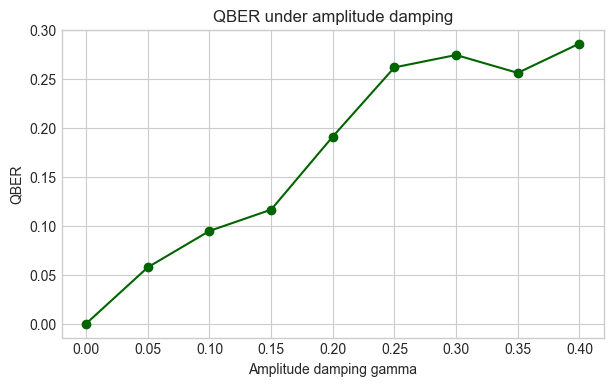

In [3]:
# Create an amplitude damping noise model
def amplitude_damping_noise_model(gamma):
    noise = NoiseModel()
    error = amplitude_damping_error(gamma)
    noise.add_all_qubit_quantum_error(error, ["x", "h", "measure"])
    return noise

gammas = np.linspace(0, 0.40, 9)
rows = []
for gamma in gammas:
    result = simulate_bb84(n=512, noise_model=amplitude_damping_noise_model(float(gamma)))
    rows.append({"Damping gamma": gamma, "Sifted key length": result["sifted_key_length"], "QBER": result["qber"]})

table = pd.DataFrame(rows)
display(table)

plt.figure(figsize=(7, 4))
plt.plot(table["Damping gamma"], table["QBER"], marker="o", color="darkgreen")
plt.xlabel("Amplitude damping gamma")
plt.ylabel("QBER")
plt.title("QBER under amplitude damping")
plt.show()

## Conclusion
Amplitude damping biases outcomes toward 0 and introduces detectable mismatches. Higher damping makes the BB84 key less reliable.